## Preliminary

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\FUFA Code\\Match-Analysis\\data\\processed\\FWSL26_mid_season_cleaned.csv')

In [133]:
df.shape

(562, 89)

In [134]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [135]:
df['match_day'] = df['match_day'].str.replace('Wmd', 'MD')

In [136]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled


In [137]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [138]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

## Summary

In [139]:
table1 = df[['player_load','power_score_wkg','work_ratio']].agg(['sum', 'mean', 'std']).T
style_table_for_docs(table1.round(2))

,sum,mean,std
player_load,229273.580000,407.960000,66.890000
power_score_wkg,7485.010000,13.320000,2.170000
work_ratio,39023.280000,69.440000,13.680000


In [140]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity.round(2))

,max,mean,std
player_load,633.770000,407.960000,66.890000
top_speed_kmh,32.350000,26.010000,2.070000
distance_per_min_mmin,116.750000,85.370000,13.620000
power_score_wkg,18.490000,13.320000,2.170000
work_ratio,106.560000,69.440000,13.680000
max_acceleration_mss,9.810000,5.330000,0.560000
max_deceleration_mss,10.000000,6.590000,0.930000
acc_counts_per_min,6.970000,4.120000,0.790000
dec_counts_per_min,6.850000,4.010000,0.780000


In [141]:
summary_table_volume = df[volume_metrics].agg(['sum','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,mean,std
distance_km,4685.840000,8.340000,1.310000
sprint_distance_m,279133.850000,496.680000,230.140000
power_plays,24584.000000,43.740000,14.340000
energy_kcal,468660.680000,833.920000,159.780000
impacts,3568.000000,6.350000,6.460000
total_accelerations,225897.000000,401.950000,76.310000
total_decelerations,219953.000000,391.380000,75.160000


## Data Overview

In [142]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
5,She Maroons Fc,19
3,Lady Doves Fc,17
0,Amus College Wfc,17
4,Makerere University Wfc,17
1,Kampala Queens Fc,14
6,Uganda Martyrs Hs Wfc,12
2,Kawempe Muslim Lfc,11


In [143]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

,p_name,player_club_,unique_match_days
1,Agnes Nabukenya,Kawempe Muslim Lfc,11
8,Asia Nakibuuka,Kawempe Muslim Lfc,11
6,Amina Nakato,Kawempe Muslim Lfc,11
35,Hadijah Babirye,Kawempe Muslim Lfc,11
60,Lilian Veronicah Masinde,She Maroons Fc,11
72,Nagadya Catherine,Kampala Queens Fc,11
70,Nabulime Jamilah,Kampala Queens Fc,11
54,Kauthra Naluyima,She Maroons Fc,11
56,Krusum Namutebi,Kawempe Muslim Lfc,11
57,Latifah Nakasi,Kawempe Muslim Lfc,11


In [144]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
5,She Maroons Fc,10.363636
2,Kawempe Muslim Lfc,10.000000
0,Amus College Wfc,9.333333
4,Makerere University Wfc,9.000000
6,Uganda Martyrs Hs Wfc,8.750000
1,Kampala Queens Fc,8.454545
3,Lady Doves Fc,6.111111


In [145]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
1,Kampala Queens Fc,11
2,Kawempe Muslim Lfc,11
5,She Maroons Fc,11
4,Makerere University Wfc,10
3,Lady Doves Fc,9
0,Amus College Wfc,6
6,Uganda Martyrs Hs Wfc,4


C:\Users\Travail\AppData\Local\Temp\ipykernel_11152\1067977572.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)


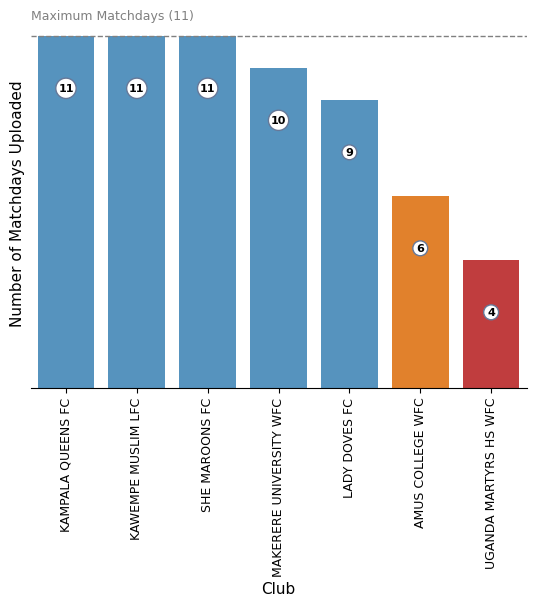

In [146]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding colors
def usage_tier_color(val):
    if val >= 8:
        return "#4596cf"  # dark blue for high engagement
    elif val >= 5:
        return '#ff7f0e'  # orange for medium
    else:
        return '#d62728'  # red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(data=data, x='club_for',hue='club_for', y='unique_matchdays', palette=colors,legend=False)

# Benchmark line at maximum matchdays (22)
plt.axhline(11, color='gray', linestyle='--', linewidth=1)
plt.text(-0.5, 11.5, 'Maximum Matchdays (11)', color='gray', fontsize=9)

# Rotate and uppercase x labels
ax = plt.gca()
ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)

# Title, subtitle, and axis labels
plt.xlabel('Club', fontsize=11)
plt.ylabel('Number of Matchdays Uploaded', fontsize=11)

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 1.8, str(value),
        ha='center', va='bottom',
        fontsize=8, color='black', fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.22", edgecolor='#667898', facecolor='white', linewidth=1)
    )
#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])


plt.show()


In [ ]:
# uploaded_matches = {
#     "She Maroons FC": 20,
#     "Kawempe Muslim LFC": 22,
#     "Uganda Martyrs Lubaga WFC": 18,
#     "Rines SS WFC": 22,
#     "Amus College WFC": 19,
#     "Wakiso Hill WFC": 18,
#     "Lady Doves FC": 16,
#     "Makerere University WFC": 22,
#     "Kampala Queens FC": 17,
#     "Olila HS WFC": 13,
#     "She Corporates FC": 5,
#     "FC Tooro Queens": 0,
    
# }

# uploaded_matches_df = pd.DataFrame(uploaded_matches.items(), columns=['club_for', 'uploaded_matches'])
# uploaded_matches_df['club_for'] = uploaded_matches_df['club_for'].str.title()

# uploaded_matches_df=uploaded_matches_df.merge(unique_matchdays_per_club, on='club_for', how='left').sort_values(by='unique_matchdays', ascending=False)
# uploaded_matches_df = uploaded_matches_df.rename(columns={
#     'uploaded_matches': 'Uploaded Matchdays',
#     'unique_matchdays': 'Analysed Matchdays',
# })

In [ ]:

# # Prepare DataFrame
# uploaded_matches_df_copy = uploaded_matches_df.copy()
# uploaded_matches_df_copy['Analysed']      = uploaded_matches_df_copy['Analysed Matchdays']
# uploaded_matches_df_copy['Pending']       = uploaded_matches_df_copy['Uploaded Matchdays'] - uploaded_matches_df_copy['Analysed Matchdays']
# uploaded_matches_df_copy['not_uploaded']  = 22 - uploaded_matches_df_copy['Uploaded Matchdays']
# uploaded_matches_df_copy = uploaded_matches_df_copy.sort_values('Analysed Matchdays', ascending=False)

# # Lighter color palette
# colors = {
#     'Analysed':      "#38759e",  # softer blue
#     'Pending':       "#ee9d50",  # softer orange
#     'not_uploaded':  "#f8373a"   # softer red
# }

# fig, ax = plt.subplots(figsize=(12,6))
# x = np.arange(len(uploaded_matches_df_copy))

# # Plot segments
# ax.bar(x, uploaded_matches_df_copy['Analysed'],
#        color=colors['Analysed'],
#        label='Analysed')
# ax.bar(x, uploaded_matches_df_copy['Pending'],
#        bottom=uploaded_matches_df_copy['Analysed'],
#        color=colors['Pending'],
#        label='Uploaded – Not Analysed')
# ax.bar(x, uploaded_matches_df_copy['not_uploaded'],
#        bottom=uploaded_matches_df_copy['Analysed'] + uploaded_matches_df_copy['Pending'],
#        color=colors['not_uploaded'],
#        label='Not Uploaded')

# # Benchmark line
# ax.axhline(22, color='gray', linestyle='--', linewidth=1)
# ax.text(-0.5, 22.5, 'MAXIMUM (22)', color='gray', fontsize=9)

# # X labels
# ax.set_xticks(x)
# ax.set_xticklabels(uploaded_matches_df_copy['club_for'].str.upper(), rotation=90, fontsize=9)

# # Clean Y axis
# ax.set_yticks([])
# ax.set_ylabel('')

# # Titles
# ax.set_xlabel('CLUB', fontsize=11)
# ax.set_title('MATCHDAY COVERAGE PER CLUB', fontsize=14, fontweight='bold',pad='30')

# # Gridlines
# ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# ax.set_axisbelow(True)

# # Remove spines
# sns.despine(ax=ax, left=True, top=True, right=True)

# # Annotation helper
# def draw_circle_text(xpos, ypos, txt, color):
#     ax.text(
#         xpos, ypos, str(int(txt)),
#         ha='center', va='center', color='black',
#         fontsize=8, fontweight='bold',
#         bbox=dict(boxstyle="circle,pad=0.3", facecolor='white', edgecolor='none')
#     )

# # Annotate segments
# for idx, row in enumerate(uploaded_matches_df_copy.itertuples()):
#     analysed = row.Analysed
#     pending  = row.Pending
#     notup    = row.not_uploaded

#     # Analysed (always)
#     if analysed > 0:
#         draw_circle_text(idx, analysed / 2, analysed, colors['Analysed'])

#     # Pending (always)
#     if pending > 1:
#         draw_circle_text(idx, analysed + pending / 2, pending, colors['Pending'])

#     # not_uploaded (only if > 1)
#     if notup > 1:
#         ypos = analysed + pending + notup / 2
#         draw_circle_text(idx, ypos, notup, colors['not_uploaded'])

# # Legend outside
# ax.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     frameon=False
# )

# plt.tight_layout()
# plt.show()


In [ ]:
# import matplotlib.patches as mpatches

# # 1. Get sorted lists of clubs & matchdays
# clubs = sorted(df['club_for'].unique())

# # Sort matchdays in correct order: MD1, MD2, ..., MD22
# matchday_order = [f'MD{i}' for i in range(1, 23)]
# matchdays = [md for md in matchday_order if md in df['match_day'].unique()]

# # 2. Build a binary grid (1 = analysed, 0 = missing)
# grid_data = []
# for md in matchdays:
#     row = []
#     for club in clubs:
#         mask = (df['match_day'] == md) & (df['club_for'] == club)
#         is_present = 1 if df.loc[mask, 'p_name'].nunique() > 0 else 0
#         row.append(is_present)
#     grid_data.append(row)

# # 3. Convert to DataFrame
# grid_df = pd.DataFrame(grid_data, index=matchdays, columns=clubs)

# # 4. Define colors
# color_map = {1: '#5cb85c', 0: '#d9534f'}  # green = uploaded, red = missing

# # 5. Plot
# fig, ax = plt.subplots(figsize=(len(clubs)*0.6 + 2, len(matchdays)*0.4 + 2))

# for y, md in enumerate(matchdays):
#     for x, club in enumerate(clubs):
#         val = grid_df.loc[md, club]
#         color = color_map[val]
#         rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor='white')
#         ax.add_patch(rect)

# # 6. Axis Labels
# ax.set_xticks(np.arange(len(clubs)) + 0.5)
# ax.set_xticklabels([c.upper() for c in clubs], rotation=90, fontsize=9)
# ax.set_yticks(np.arange(len(matchdays)) + 0.5)
# ax.set_yticklabels([i.upper() for i in matchdays], fontsize=9)

# ax.set_xlim(0, len(clubs))
# ax.set_ylim(0, len(matchdays))
# ax.invert_yaxis()

# ax.set_xlabel('Club', fontsize=11)
# ax.set_ylabel('Match Day', fontsize=11)
# ax.set_title('Matchdays Analysed per Club', fontsize=13, fontweight='bold')

# # 7. Legend
# handles = [
#     mpatches.Patch(color=color_map[1], label='Analysed Matchday'),
#     mpatches.Patch(color=color_map[0], label='Missing Matchday')
# ]
# ax.legend(handles=handles, title='Color Map', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

# plt.tight_layout()
# plt.show()


In [193]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 12)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

C:\Users\Travail\AppData\Local\Temp\ipykernel_11152\1606782026.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()


,match_day,total_player_entries
0,Md1,52
1,Md2,54
2,Md3,45
3,Md4,51
4,Md5,54
5,Md6,52
6,Md7,61
7,Md8,55
8,Md9,55
9,Md10,47


In [194]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 12)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


C:\Users\Travail\AppData\Local\Temp\ipykernel_11152\4219517520.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()


,match_day,num_clubs
0,Md1,6
1,Md2,6
2,Md3,5
3,Md4,5
4,Md5,6
5,Md6,6
6,Md7,7
7,Md8,6
8,Md9,6
9,Md10,5


In [152]:

def plot_line_with_values(data, x_col, y_col, title=None, x_label=None,y_label=None, figsize=(10, 6)):
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the line
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)

    
    # Get current axis
    ax = plt.gca()
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set spine and tick colors to light gray
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)
    

    if x_col == 'match_day':
        # Ensure match_day is ordered as per matchday_order
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(Wmd).replace('Wmd', 'Wmd ') for Wmd in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90)
        # Re-plot with sorted data to ensure correct order
        
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
        
    # Add value labels above each point
    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}', 
            (x, y),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )
    
    # Set title
    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)

    # #start the y-axis at 0
    # ax.set_ylim(bottom=2,top=14)  # Adjust the top limit as needed
    

    # Set labels
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    # Adjust layout
    plt.tight_layout()
    
    return ax

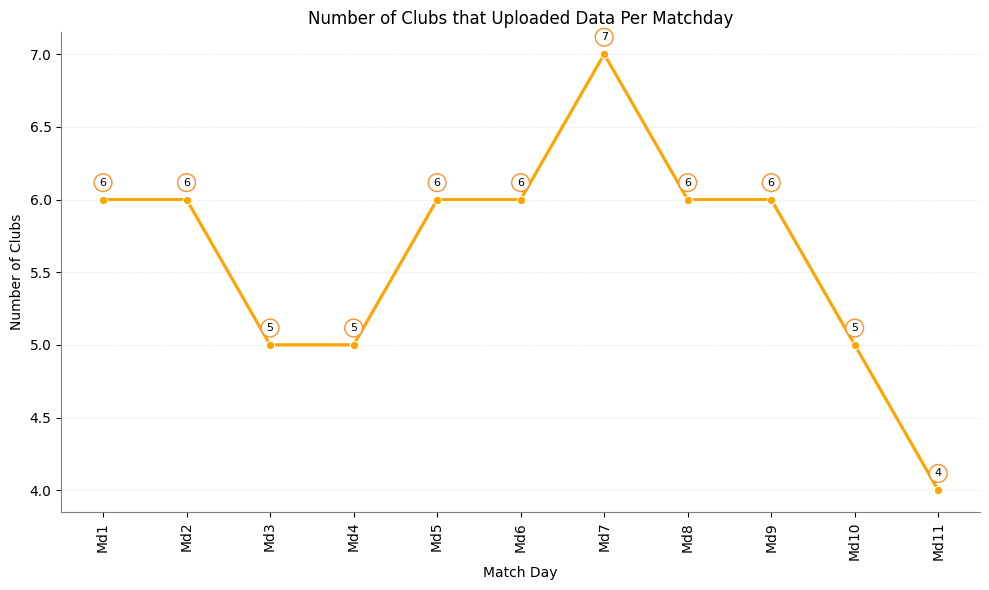

In [153]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Number of Clubs that Uploaded Data Per Matchday',x_label='Match Day', y_label='Number of Clubs');

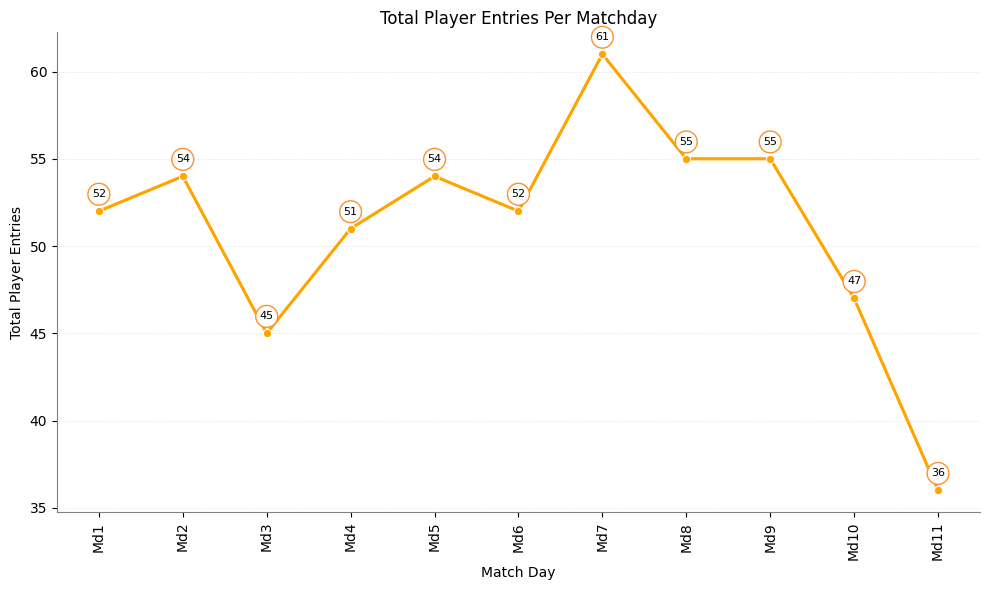

In [154]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [155]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,location,count,percentage
0,Home,292,51.957295
1,Away,270,48.042705


In [156]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,result,count,percentage
0,Win,258,45.907473
1,Draw,162,28.825623
2,Loss,142,25.266904


In [157]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Kawempe Muslim Lfc,9,1,1
Kampala Queens Fc,6,3,2
She Maroons Fc,4,3,4
Amus College Wfc,3,2,1
Lady Doves Fc,2,4,3
Makerere University Wfc,2,4,4
Uganda Martyrs Hs Wfc,2,1,1


### Max Metrics

In [158]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

,max,mean,std
top_speed_kmh,32.352120,26.008550,2.074163
distance_per_min_mmin,116.753649,85.373997,13.622128
max_acceleration_mss,9.811200,5.325920,0.562174
max_deceleration_mss,10.000000,6.589127,0.933760


In [159]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

,sum,max,mean,std
distance_in_speed_zone_1_km,572818.800000,4261.400000,1019.250000,385.800000
distance_in_speed_zone_2_km,2496922.400000,6159.600000,4442.920000,722.460000
distance_in_speed_zone_3_km,1336957.400000,4701.800000,2378.930000,713.100000
distance_in_speed_zone_4_km,262691.700000,1221.900000,467.420000,203.080000
distance_in_speed_zone_5_km,16440.600000,210.800000,29.250000,40.040000


## Analysis

### Club Comparison

In [160]:
club_metrics_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics+intensity_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
style_table_for_docs(club_metrics_mean.round(2))


,club_for,avg_distance_km,avg_sprint_distance_m,avg_power_plays,avg_energy_kcal,avg_impacts,avg_total_accelerations,avg_total_decelerations,avg_player_load,avg_top_speed_kmh,avg_distance_per_min_mmin,avg_power_score_wkg,avg_work_ratio,avg_max_acceleration_mss,avg_max_deceleration_mss,avg_acc_counts_per_min,avg_dec_counts_per_min
0,Lady Doves Fc,8.530000,491.020000,42.730000,784.180000,6.380000,399.290000,387.270000,417.570000,26.240000,86.650000,13.450000,71.040000,5.410000,6.460000,4.050000,3.930000
1,Kampala Queens Fc,8.380000,508.130000,44.030000,818.700000,6.910000,427.180000,410.930000,426.680000,26.840000,87.250000,13.630000,69.910000,5.360000,6.840000,4.450000,4.280000
2,Makerere University Wfc,8.360000,456.800000,40.940000,767.690000,7.730000,403.740000,394.080000,412.810000,25.380000,82.980000,12.930000,69.400000,5.220000,6.520000,4.000000,3.910000
3,She Maroons Fc,8.340000,531.710000,45.790000,942.400000,5.260000,393.470000,383.870000,401.650000,26.030000,86.580000,13.540000,70.820000,5.240000,6.600000,4.090000,3.990000
4,Kawempe Muslim Lfc,8.300000,499.830000,45.260000,846.350000,4.980000,402.360000,391.070000,396.690000,25.870000,88.440000,13.820000,70.850000,5.430000,6.560000,4.290000,4.170000
5,Amus College Wfc,8.090000,483.060000,42.830000,793.210000,5.040000,380.490000,373.790000,387.600000,26.020000,79.170000,12.350000,64.200000,5.330000,6.460000,3.720000,3.650000
6,Uganda Martyrs Hs Wfc,7.890000,446.440000,38.750000,764.890000,10.050000,381.600000,378.190000,395.910000,25.640000,75.890000,11.790000,59.920000,5.270000,6.520000,3.670000,3.640000


In [161]:
team_avg_dist_per_match = (
    df
    .groupby(['club_for', 'match_day'], observed=False)['distance_km']
    .sum()  # Total team distance on a match day
    .groupby('club_for')
    .mean()  # Average total team distance per match across all match days
    .reset_index(name='avg_team_distance_per_match_km')
    .sort_values(by='avg_team_distance_per_match_km', ascending=False)
)
style_table_for_docs(team_avg_dist_per_match)

,club_for,avg_team_distance_per_match_km
5,She Maroons Fc,86.255118
2,Kawempe Muslim Lfc,82.984764
0,Amus College Wfc,75.512983
4,Makerere University Wfc,75.343870
1,Kampala Queens Fc,70.786927
6,Uganda Martyrs Hs Wfc,69.861200
3,Lady Doves Fc,62.175433


In [162]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max.round(2))

,club_for,max_top_speed_kmh,max_distance_per_min_mmin
0,Kawempe Muslim Lfc,32.350000,106.490000
1,Kampala Queens Fc,31.930000,110.700000
2,She Maroons Fc,30.800000,111.640000
3,Makerere University Wfc,29.960000,111.560000
4,Uganda Martyrs Hs Wfc,29.780000,104.790000
5,Amus College Wfc,29.760000,103.870000
6,Lady Doves Fc,29.490000,116.750000


In [163]:
club_intensity_avg = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_avg.round(2))

,club_for,avg_top_speed_kmh,avg_distance_per_min_mmin
0,Kampala Queens Fc,26.860000,87.250000
1,Amus College Wfc,26.070000,79.460000
2,She Maroons Fc,26.010000,86.360000
3,Lady Doves Fc,25.990000,89.030000
4,Kawempe Muslim Lfc,25.870000,88.440000
5,Uganda Martyrs Hs Wfc,25.800000,76.790000
6,Makerere University Wfc,25.360000,82.850000


### Metric High Scores

In [164]:
# For each metric in volume_metrics, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Faith Apio,She Maroons Fc,11.277600,Md10
1,sprint_distance_m,Doreen Monica Nakayiwa,She Maroons Fc,1418.194000,Md8
2,power_plays,Doreen Monica Nakayiwa,She Maroons Fc,85.000000,Md7
3,energy_kcal,Faith Apio,She Maroons Fc,1324.454000,Md10
4,impacts,Moureen Kiiza,Uganda Martyrs Hs Wfc,87.000000,Md9
5,total_accelerations,Namusoke Esther,Kampala Queens Fc,679.000000,Md5
6,total_decelerations,Moureen Kiiza,Uganda Martyrs Hs Wfc,714.000000,Md7
7,player_load,Namusoke Esther,Kampala Queens Fc,633.769000,Md5
8,top_speed_kmh,Jovia Nakagolo,Kawempe Muslim Lfc,32.352120,Md9
9,distance_per_min_mmin,Lydia Nyandera,Lady Doves Fc,116.753649,Md4


### Comparison by Position Group

In [165]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defenders,8.230000,465.030000,40.790000,801.870000,6.050000,410.520000,396.630000
Forwards,8.130000,628.080000,50.080000,845.500000,6.870000,371.160000,364.090000
Midfielders,8.650000,420.800000,41.790000,862.050000,6.240000,418.370000,408.700000


In [166]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defenders,403.452547,13.091586,67.723664,4.200661,4.057148
Forwards,393.305839,13.133878,66.029926,3.810634,3.739077
Midfielders,425.988263,13.748174,74.418702,4.278782,4.179182


In [167]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,29.960000,108.900000,6.970000,6.850000
Forwards,32.350000,102.160000,5.230000,5.150000
Midfielders,29.490000,116.750000,6.280000,6.010000


In [168]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,26.030000,84.160000,4.200000,4.060000
Forwards,27.290000,83.490000,3.810000,3.740000
Midfielders,24.870000,88.450000,4.280000,4.180000


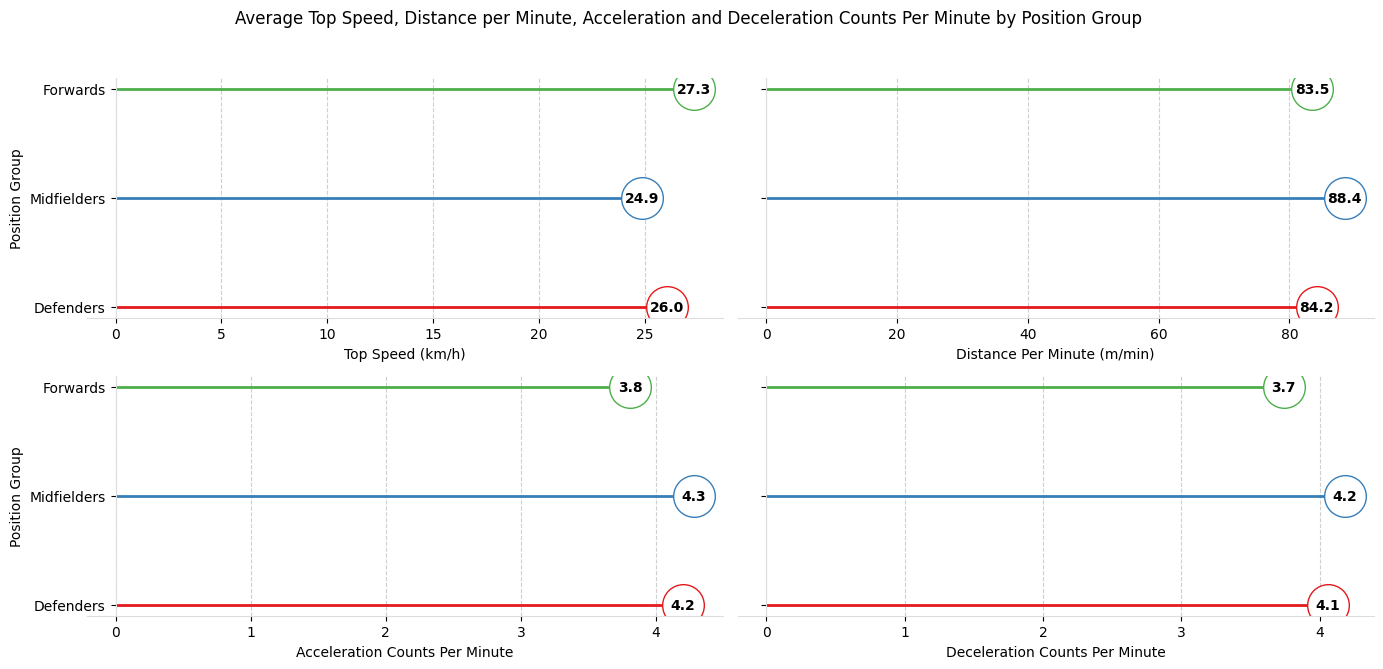

In [169]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

# Define the order of position groups
position_order = ['Defenders', 'Midfielders', 'Forwards']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 30

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'top_speed_kmh':
            text_val = f'{val:.1f}'
        elif metric == 'distance_per_min_mmin':
            text_val = f'{val:.1f}'
        elif metric == 'acc_counts_per_min':
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.1f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=10, color='black', fontweight='bold')

    yticklabels = [f"{pos}" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Top Speed, Distance per Minute, Acceleration and Deceleration Counts Per Minute by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


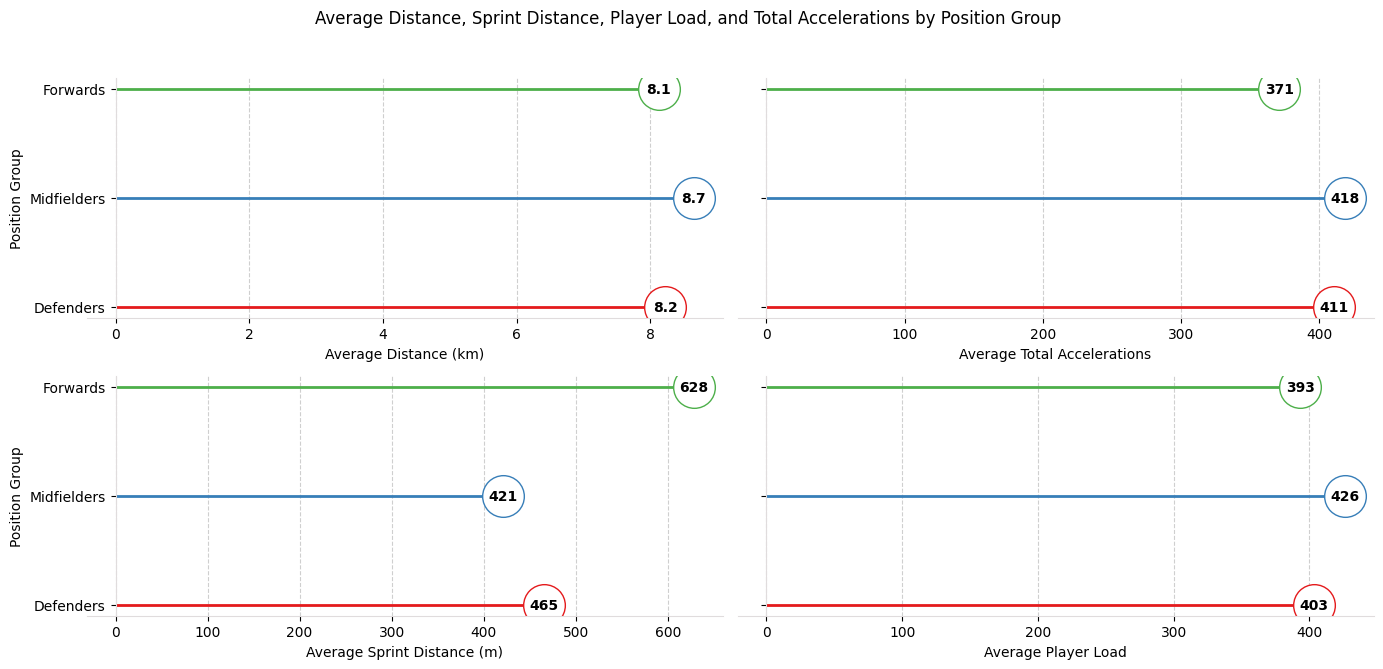

In [170]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

# Define the order of position groups
position_order = ['Defenders', 'Midfielders', 'Forwards']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 30

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=10, color='black', fontweight='bold')

    yticklabels = [f"{pos}" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Distance, Sprint Distance, Player Load, and Total Accelerations by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Comparison by Location

In [171]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
location,,,,,,,
Away,8.290000,499.920000,43.760000,832.160000,6.790000,398.310000,388.370000
Home,8.380000,493.690000,43.730000,835.540000,5.940000,405.320000,394.160000


In [172]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics ]].mean()
style_table_for_docs(avg_intensity_by_location)

,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
location,,,,,,,,,
Away,406.796871,25.991025,85.813836,13.379726,69.569324,5.320707,6.679872,4.122553,4.018864
Home,409.035690,26.024755,84.967297,13.261925,69.313576,5.330740,6.505218,4.109733,3.996250


In [173]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].max().round(2)
style_table_for_docs(avg_intensity_by_location_)

,top_speed_kmh,distance_per_min_mmin
location,,
Away,31.930000,116.750000
Home,32.350000,111.640000


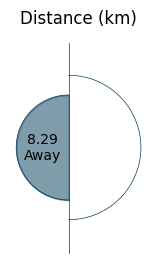

In [174]:
def plot_home_away_top_speed(avg_volume_by_location, color='#003b59', min_radius=0.8, max_radius=1.1):
    """
    Plot a semicircle comparison of top speed (km/h) for Home vs Away using avg_volume_by_location DataFrame.
    """
    home_speed = avg_volume_by_location.loc['Home', 'distance_km']
    away_speed = avg_volume_by_location.loc['Away', 'distance_km']

    speeds = np.array([home_speed, away_speed])
    norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
    home_radius, away_radius = norm_radii

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal')
    ax.axis('off')

    # Draw right (Home) semicircle
    theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
    x_home = home_radius * np.cos(theta_home)
    y_home = home_radius * np.sin(theta_home)
    ax.plot(x_home, y_home, color=color, linewidth=0.5)
    if home_radius < away_radius:
        ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

    # Draw left (Away) semicircle
    theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
    x_away = away_radius * np.cos(theta_away)
    y_away = away_radius * np.sin(theta_away)
    ax.plot(x_away, y_away, color=color, linewidth=0.5)
    if away_radius < home_radius:
        ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

    # Draw the separating line
    ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

    # Place values inside semicircles
    ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')
    ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')

    plt.title('Distance (km)', fontsize=12)
    plt.show()
plot_home_away_top_speed(avg_volume_by_location)

### Metric Distribution 

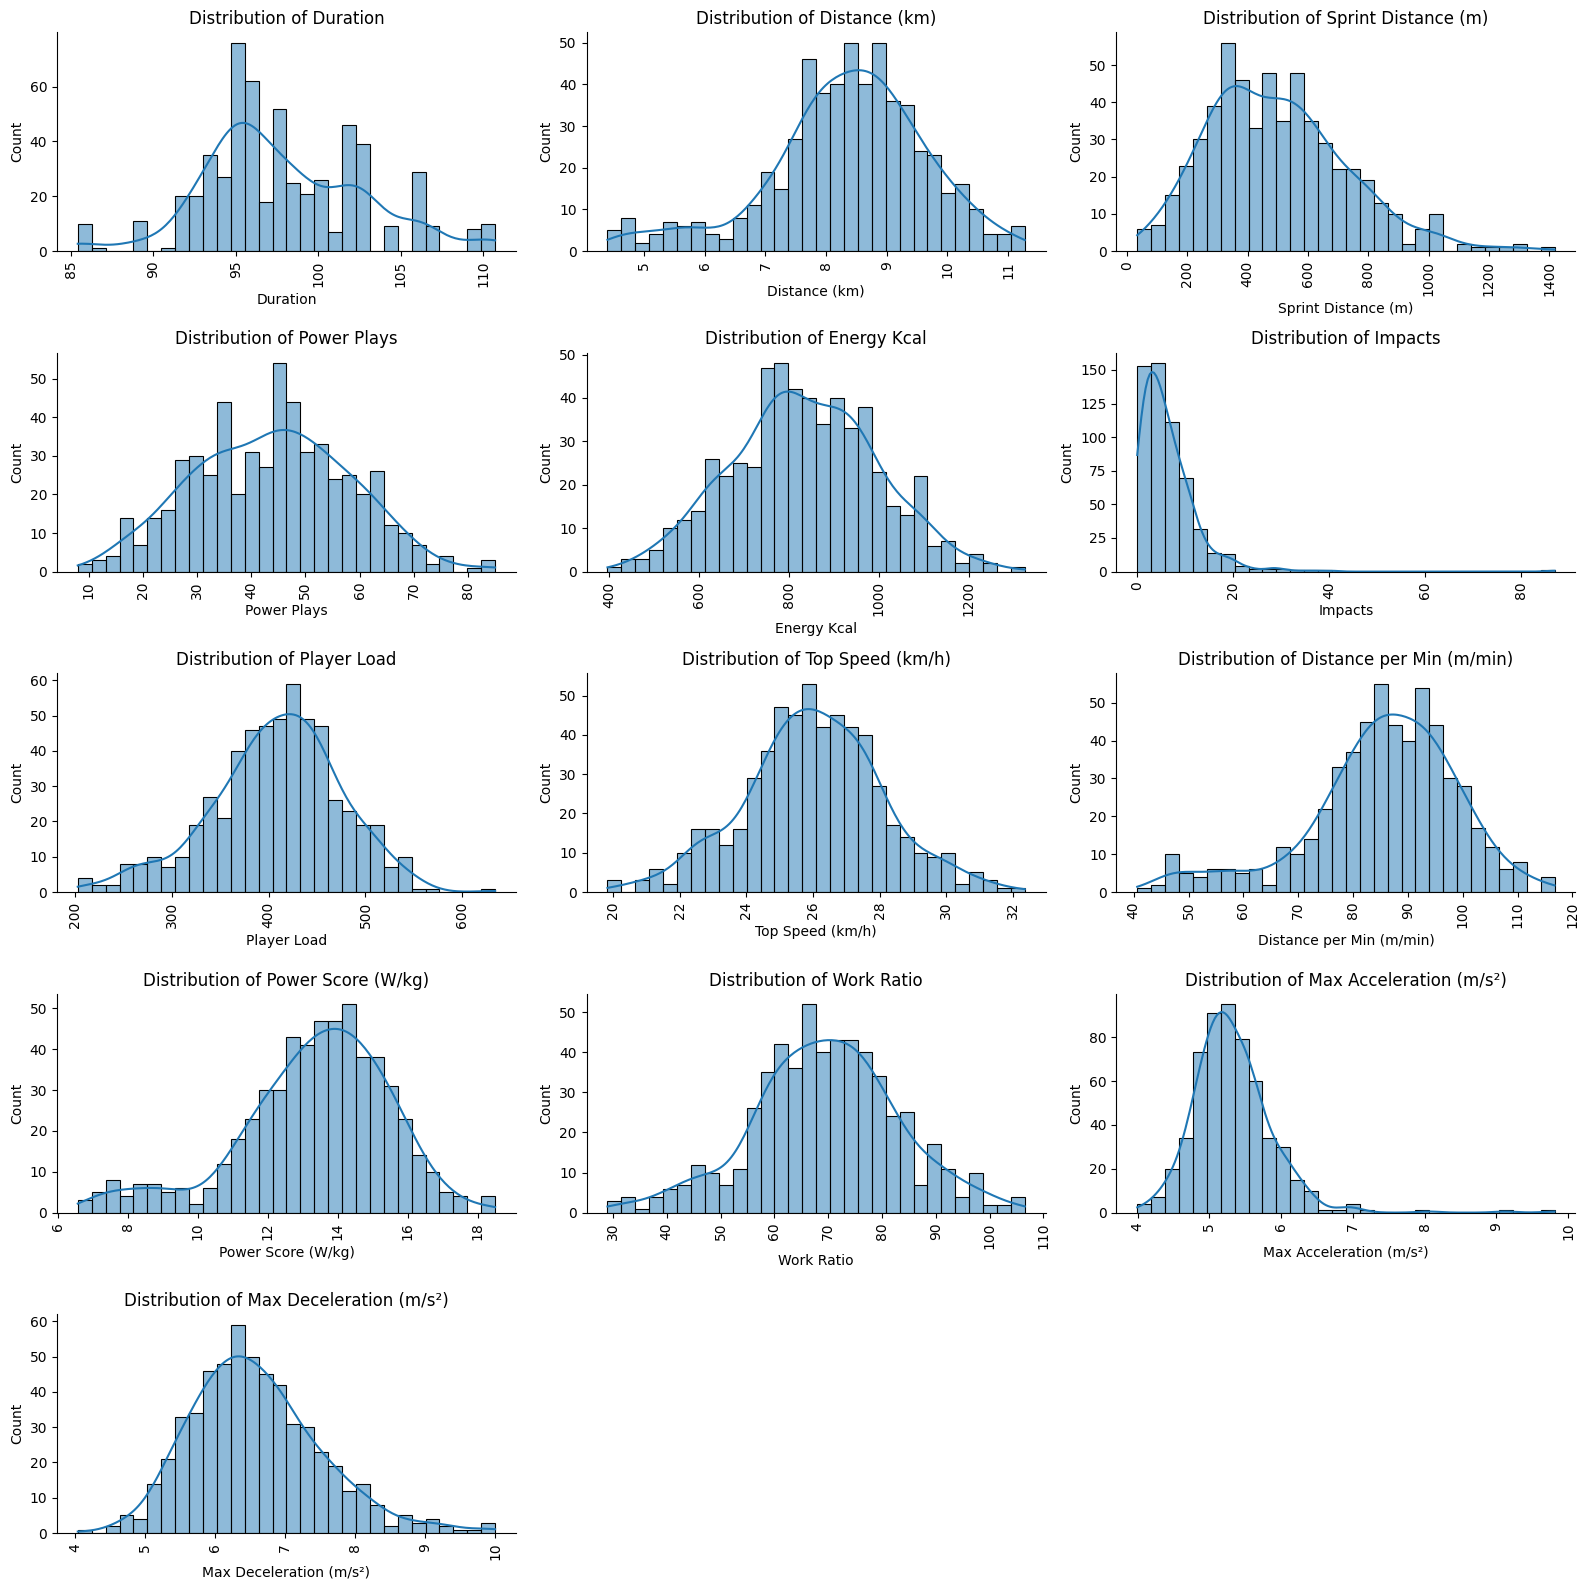

In [175]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    # Format title and x-label: replace _ with space, capitalize, add units if present
    label = col.replace('_', ' ').title()
    # Add units for specific columns
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'max_acceleration_mss':
        label = 'Max Acceleration (m/s²)'
    elif col == 'max_deceleration_mss':
        label = 'Max Deceleration (m/s²)'
    elif col == 'acc_counts_per_min':
        label = 'Acc. Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Dec. Counts per Min'
    
    plt.title(f'Distribution of {label}')
    plt.xlabel(label)
    plt.xticks(rotation=90)
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



## Trend Analysis

In [176]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.180000,413.170000,41.040000,822.670000,5.440000,416.290000,405.920000,405.850000,25.750000,82.780000,13.000000,68.430000,5.330000,6.490000,4.210000,4.110000
3,Md2,8.300000,505.820000,43.560000,830.870000,5.850000,393.110000,382.220000,404.800000,26.130000,84.010000,13.070000,68.220000,5.300000,6.520000,3.980000,3.870000
4,Md3,7.810000,444.940000,40.330000,791.700000,5.580000,379.780000,369.470000,379.430000,25.810000,80.340000,12.510000,64.500000,5.240000,6.700000,3.910000,3.810000
5,Md4,8.980000,521.800000,46.820000,882.250000,7.020000,425.630000,413.860000,438.610000,25.680000,92.510000,14.430000,76.670000,5.390000,6.500000,4.390000,4.270000
6,Md5,8.310000,453.200000,41.370000,833.870000,5.130000,421.390000,409.240000,411.730000,25.560000,83.370000,13.050000,68.040000,5.240000,6.410000,4.240000,4.110000
7,Md6,8.460000,551.570000,47.270000,835.740000,6.960000,402.270000,390.350000,407.690000,26.490000,87.670000,13.720000,71.910000,5.440000,6.910000,4.170000,4.050000
8,Md7,8.300000,459.690000,43.560000,827.500000,7.660000,409.980000,405.930000,410.040000,25.640000,84.930000,13.310000,68.430000,5.330000,6.670000,4.190000,4.150000
9,Md8,8.360000,579.340000,46.090000,839.190000,5.530000,377.450000,365.440000,400.370000,26.420000,88.110000,13.660000,71.450000,5.400000,6.740000,3.980000,3.850000
10,Md9,8.270000,492.900000,42.040000,816.690000,8.020000,396.910000,386.350000,406.590000,26.420000,84.460000,13.110000,68.470000,5.360000,6.590000,4.060000,3.950000
1,Md10,8.410000,515.400000,44.190000,846.410000,6.660000,394.340000,384.130000,412.580000,26.000000,85.160000,13.260000,69.550000,5.250000,6.290000,3.990000,3.890000


In [177]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.180000,413.170000,41.040000,822.670000,5.440000,416.290000,405.920000,405.850000,25.750000,82.780000,13.000000,68.430000,5.330000,6.490000,4.210000,4.110000
1,Md2,8.240000,459.490000,42.300000,826.770000,5.650000,404.700000,394.070000,405.320000,25.940000,83.390000,13.040000,68.320000,5.310000,6.510000,4.100000,3.990000
2,Md3,8.100000,454.640000,41.640000,815.080000,5.620000,396.390000,385.870000,396.690000,25.900000,82.370000,12.860000,67.050000,5.290000,6.570000,4.030000,3.930000
3,Md4,8.360000,490.850000,43.570000,834.940000,6.150000,399.510000,388.520000,407.620000,25.870000,85.620000,13.340000,69.800000,5.310000,6.580000,4.090000,3.980000
4,Md5,8.370000,473.310000,42.840000,835.940000,5.910000,408.930000,397.520000,409.930000,25.680000,85.410000,13.330000,69.740000,5.290000,6.540000,4.180000,4.060000
5,Md6,8.580000,508.860000,45.150000,850.620000,6.370000,416.430000,404.480000,419.340000,25.910000,87.850000,13.730000,72.210000,5.360000,6.610000,4.270000,4.140000
6,Md7,8.350000,488.150000,44.070000,832.370000,6.580000,411.210000,401.840000,409.820000,25.900000,85.320000,13.360000,69.460000,5.340000,6.660000,4.200000,4.100000
7,Md8,8.370000,530.200000,45.640000,834.150000,6.710000,396.570000,387.240000,406.030000,26.180000,86.900000,13.560000,70.600000,5.390000,6.770000,4.110000,4.020000
8,Md9,8.310000,510.640000,43.890000,827.790000,7.070000,394.780000,385.910000,405.670000,26.160000,85.830000,13.360000,69.450000,5.370000,6.670000,4.070000,3.980000
9,Md10,8.340000,529.210000,44.110000,834.100000,6.740000,389.570000,378.640000,406.510000,26.280000,85.910000,13.340000,69.820000,5.340000,6.540000,4.010000,3.900000


In [178]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# metrics = [
#     ('distance_km', 'Distance (km)'),
#     ('sprint_distance_m', 'Sprint Distance (m)'),
#     ('player_load', 'Player Load'),
#     ('top_speed_kmh', 'Top Speed (km/h)')
# ]

# # Get valid match days (non-NaN)
# valid_matchdays = rolling_avg['match_day'].dropna().tolist()
# MD11_idx = valid_matchdays.index('MD11') if 'MD11' in valid_matchdays else None
# last_idx = len(valid_matchdays) - 1

# for ax, (col, label) in zip(axes.flatten(), metrics):
#     sns.lineplot(
#         data=rolling_avg,
#         x='match_day',
#         y=col,
#         marker='o',
#         ax=ax,
#         label=f'Average {label}'
#     )
#     avg_value = rolling_avg[col].mean()
#     ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
#     # Draw vertical line at MD11
#     ax.axvline(MD11_idx, color='black', linestyle=':', linewidth=1)
#     # Shade area before MD11 (First Round)
#     ax.axvspan(-0.5, MD11_idx - 0.5, color='skyblue', alpha=0.35)
#     # Shade area from MD11 to last matchday (Second Round)
#     ax.axvspan(MD11_idx - 0.5, last_idx + 0.5, color='lightgreen', alpha=0.35)
#     xticklabels = [str(Wmd).replace('MD', 'MD ') for Wmd in valid_matchdays]
#     ax.set_xticks(range(len(valid_matchdays)))
#     ax.set_xticklabels(xticklabels, rotation=90)
#     ax.set_title(f'{label} Across Match Days')
#     ax.set_xlabel('Match Day')
#     ax.set_ylabel(label)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     legend = ax.legend(frameon=False)
#     ymin, ymax = ax.get_ylim()
#     ax.text(MD11_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
#     ax.text(MD11_idx + (last_idx-MD11_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

# plt.tight_layout(rect=[0, 0.01, 1, 1])
# plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
# plt.show()


## Correlation Analysis

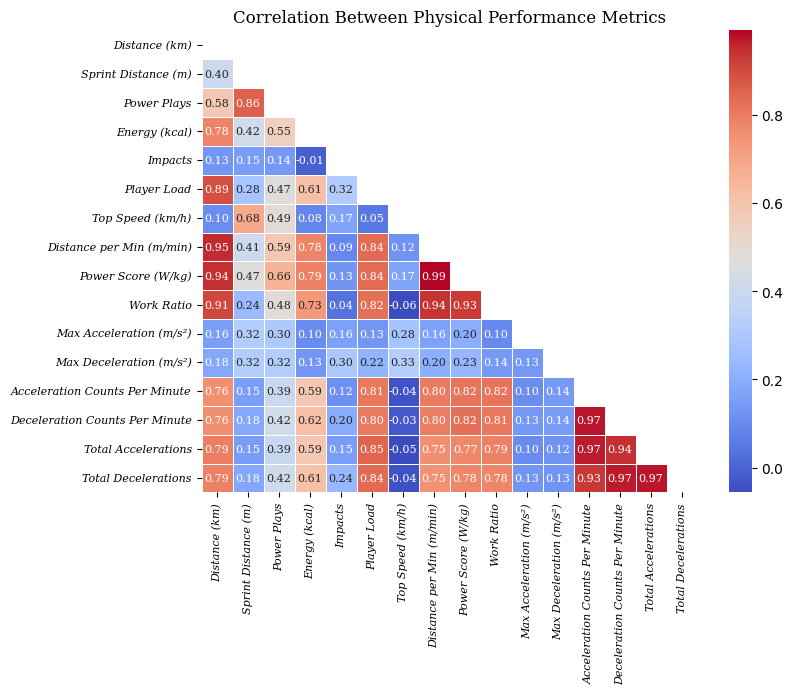

In [179]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acceleration Counts Per Minute',
    'dec_counts_per_min':'Deceleration Counts Per Minute',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    annot_kws={"fontsize":8, "fontfamily":"serif"}
)
plt.title("Correlation Between Physical Performance Metrics", fontsize=12, fontfamily="serif")
plt.xticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.yticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.show()


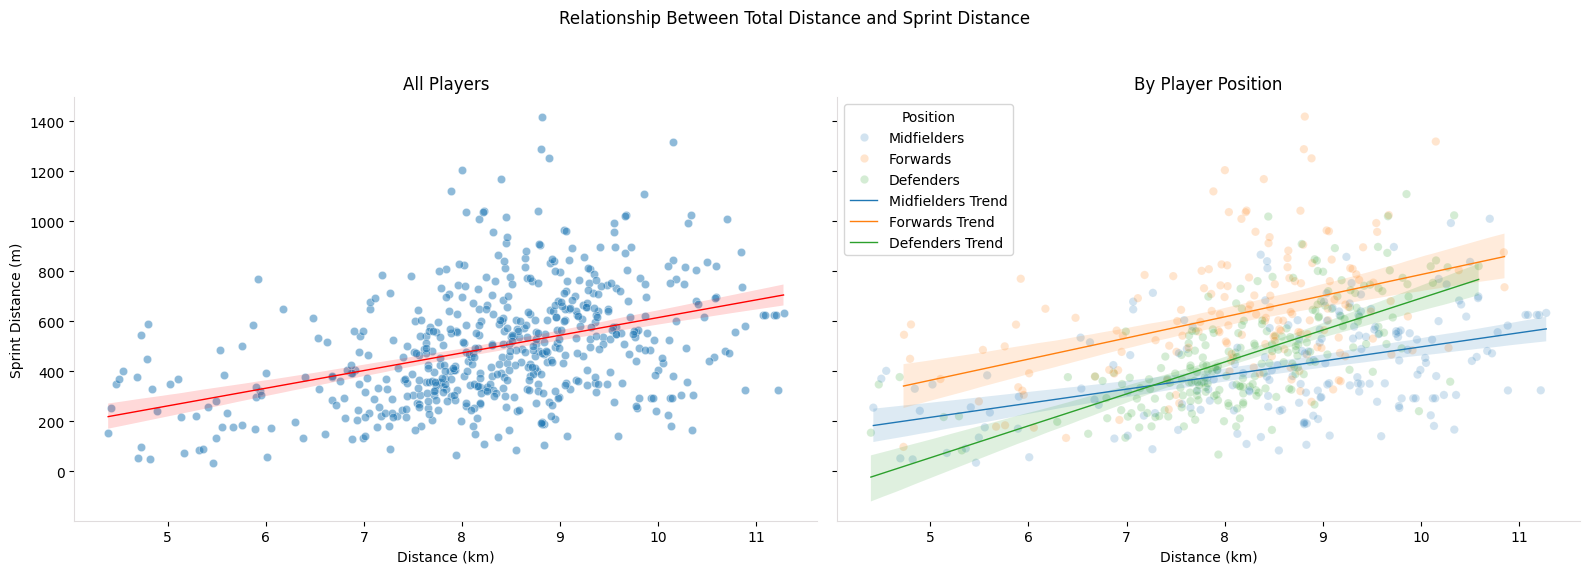

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: All players, no hue
ax1 = axes[0]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', alpha=0.5, ax=ax1)
sns.regplot(data=df, x='distance_km', y='sprint_distance_m', scatter=False, ax=ax1, color='red', line_kws={'linewidth':1})
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Sprint Distance (m)')
ax1.set_title('All Players')
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')

# Plot 2: Hue by player position, trend lines for each group
ax2 = axes[1]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', hue='general_position', alpha=0.2, ax=ax2)
for pos in df['general_position'].dropna().unique():
    sns.regplot(
        data=df[df['general_position'] == pos],
        x='distance_km',
        y='sprint_distance_m',
        scatter=False,
        ax=ax2,
        label=f"{pos} Trend",
        line_kws={'linewidth':1}
    )
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Sprint Distance (m)')
ax2.set_title('By Player Position')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.legend(title='Position')

plt.suptitle('Relationship Between Total Distance and Sprint Distance')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Other Requests

### Pairwise Performance

In [181]:
# # Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

# clubs = sorted(df['club_for'].unique())
# single_matchday_metric = []

# for i, club1 in enumerate(clubs):
#     for club2 in clubs[i+1:]:
#         # Find all matchdays where these two clubs played each other
#         matchdays = df[
#             ((df['club_for'] == club1) & (df['club_against'] == club2)) |
#             ((df['club_for'] == club2) & (df['club_against'] == club1))
#         ]['match_day'].unique()
#         for md in matchdays:
#             # Filter for only this pair and this matchday
#             mask = (
#                 (((df['club_for'] == club1) & (df['club_against'] == club2)) |
#                  ((df['club_for'] == club2) & (df['club_against'] == club1))) &
#                 (df['match_day'] == md)
#             )
#             relevant_rows = df[mask]
#             if not relevant_rows.empty:
#                 avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
#                 row = {
#                     'Team A': club1,
#                     'Team B': club2,
#                     'match_day': md
#                 }
#                 row.update(avg_metrics.to_dict())
#                 single_matchday_metric.append(row)

# single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
# single_matchday_metric_df = single_matchday_metric_df[
#     (single_matchday_metric_df['top_speed_kmh'] > 20)
# ][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] > 8)]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] > 300)]
# single_matchday_metric_df = single_matchday_metric_df.sort_values(by='player_load', ascending=False).reset_index(drop=True)

# style_table_for_docs(single_matchday_metric_df.head(10))

In [182]:
# # Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

# clubs = sorted(df['club_for'].unique())
# single_matchday_metric = []

# for i, club1 in enumerate(clubs):
#     for club2 in clubs[i+1:]:
#         # Find all matchdays where these two clubs played each other
#         matchdays = df[
#             ((df['club_for'] == club1) & (df['club_against'] == club2)) |
#             ((df['club_for'] == club2) & (df['club_against'] == club1))
#         ]['match_day'].unique()
#         for md in matchdays:
#             # Filter for only this pair and this matchday
#             mask = (
#                 (((df['club_for'] == club1) & (df['club_against'] == club2)) |
#                  ((df['club_for'] == club2) & (df['club_against'] == club1))) &
#                 (df['match_day'] == md)
#             )
#             relevant_rows = df[mask]
#             if not relevant_rows.empty:
#                 avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
#                 row = {
#                     'Team A': club1,
#                     'Team B': club2,
#                     'match_day': md
#                 }
#                 row.update(avg_metrics.to_dict())
#                 single_matchday_metric.append(row)

# single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
# single_matchday_metric_df = single_matchday_metric_df[
#     (single_matchday_metric_df['top_speed_kmh'] > 0)
# ][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] < 9)]
# single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] < 400)]
# single_matchday_metric_df = single_matchday_metric_df.sort_values(by='distance_km', ascending=True).reset_index(drop=True)

# style_table_for_docs(single_matchday_metric_df.head(10))

In [183]:
# # Create a DataFrame showing the averages of all intensity metrics for each team A when they play team B
# clubs = sorted(df['club_for'].unique())
# avg_intensity_vs_opponent = []

# for club1 in clubs:
#     for club2 in clubs:
#         if club1 == club2:
#             continue  # skip self
#         mask = (
#             ((df['club_for'] == club1) & (df['club_against'] == club2))
#         )
#         club1_rows = df[mask]
#         if not club1_rows.empty:
#             avg_metrics = club1_rows[intensity_metrics].mean()
#             row = {'Team A': club1, 'Team B': club2}
#             row.update(avg_metrics.to_dict())
#             avg_intensity_vs_opponent.append(row)

# avg_intensity_vs_opponent_df = pd.DataFrame(avg_intensity_vs_opponent)
# avg_intensity_vs_opponent_df = avg_intensity_vs_opponent_df.sort_values(by='top_speed_kmh', ascending=False).reset_index(drop=True)
# style_table_for_docs(avg_intensity_vs_opponent_df.head(10))

In [184]:
# # Create a DataFrame showing the averages of all volume metrics for each team A when they play team B
# clubs = sorted(df['club_for'].unique())
# avg_volume_vs_opponent = []

# for club1 in clubs:
#     for club2 in clubs:
#         if club1 == club2:
#             continue  # skip self
#         mask = (
#             ((df['club_for'] == club1) & (df['club_against'] == club2))
#         )
#         club1_rows = df[mask]
#         if not club1_rows.empty:
#             avg_metrics = club1_rows[volume_metrics].mean()
#             row = {'Team A': club1, 'Team B': club2}
#             row.update(avg_metrics.to_dict())
#             avg_volume_vs_opponent.append(row)

# avg_volume_vs_opponent_df = pd.DataFrame(avg_volume_vs_opponent)
# avg_volume_vs_opponent_df = avg_volume_vs_opponent_df.sort_values(by='distance_km', ascending=False).reset_index(drop=True)
# style_table_for_docs(avg_volume_vs_opponent_df.head(10))

### Top Performers for each Metric (Individual/ Team/ Pairwise)

In [185]:
# # Find top 5 players for each metric in volume_metrics and intensity_metrics
# top5_players = []

# metrics_to_check = volume_metrics + intensity_metrics
# for metric in metrics_to_check:
#     # Get top 5 rows for this metric
#     top_rows = df.nlargest(5, metric)
#     for _, row in top_rows.iterrows():
#         top5_players.append({
#             'metric': metric,
#             'player': row['p_name'],
#             'club': row['club_for'],
#             'value': row[metric],
#             'match day': row['match_day']
#         })

# top5_players_df = pd.DataFrame(top5_players)
# # Optionally, sort for display
# top5_players_df = top5_players_df.sort_values(['metric', 'value'], ascending=[True, False]).reset_index(drop=True)
# style_table_for_docs(top5_players_df)

### Best Performers in each position

In [186]:
# # Combine metrics into one list
# all_metrics = volume_metrics + intensity_metrics

# # Store top 5 players per metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     for position in df['general_position'].dropna().unique():
#         # Get top 5 players for this metric and position
#         top_rows = df[df['general_position'] == position].nlargest(5, metric)
        
#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'value': row[metric],
#                 'match day': row['match_day'],
#                 'position': position
#             })

# # Convert to DataFrame
# top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# # Sort by metric name (alphabetically) and then value (descending)
# top5_players_by_position_df = top5_players_by_position_df.sort_values(
#     ['metric', 'value'], ascending=[True, False]
# ).reset_index(drop=True)

# # Apply your styling function
# style_table_for_docs(top5_players_by_position_df)



In [187]:
# # Combine metrics into one list
# all_metrics = volume_metrics + intensity_metrics

# # Group by player and position, then average all metrics
# avg_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].mean().reset_index()

# # Store top 5 players per metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     for position in avg_df['general_position'].dropna().unique():
#         # Get top 5 players for this metric and position
#         top_rows = avg_df[avg_df['general_position'] == position].nlargest(5, metric)
        
#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'value': row[metric],
#                 'position': position
#             })

# # Convert to DataFrame
# top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# # Sort for display: alphabetically by metric, descending by value
# top5_players_by_position_df = top5_players_by_position_df.sort_values(
#     ['metric', 'value'], ascending=[True, False]
# ).reset_index(drop=True)

# # Display nicely (assuming this is your custom function)
# style_table_for_docs(top5_players_by_position_df)


In [188]:
# # Custom position sorting order
# position_order = ['Defenders', 'Midfielders', 'Forwards']

# # Step 1: Count appearances (unique match days)
# appearances_df = df.groupby(['p_name', 'general_position', 'club_for'])['match_day'].nunique().reset_index()
# appearances_df = appearances_df.rename(columns={'match_day': 'appearances'})

# # Step 2: Calculate mean and std for metrics
# metrics_stats_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].agg(['mean', 'std']).reset_index()

# # Step 3: Fix column names: flatten multi-index columns
# metrics_stats_df.columns = [
#     f"{metric}_{stat}" if stat else metric
#     for metric, stat in metrics_stats_df.columns.to_flat_index()
# ]

# # Step 4: Merge with appearances
# merged_df = metrics_stats_df.merge(
#     appearances_df,
#     on=['p_name', 'general_position', 'club_for']
# )

# # Step 5: Only include players with at least 3 appearances
# filtered_df = merged_df[merged_df['appearances'] >= 15]

# # Step 6: Extract top 5 players for each metric and position
# top5_players_by_position = []

# for metric in all_metrics:
#     mean_col = f'{metric}_mean'
#     std_col = f'{metric}_std'

#     for position in position_order:
#         group = filtered_df[filtered_df['general_position'] == position]

#         # Skip if metric column is missing
#         if mean_col not in group.columns:
#             continue

#         top_rows = group.nlargest(5, mean_col)

#         for _, row in top_rows.iterrows():
#             top5_players_by_position.append({
#                 'metric': metric,
#                 'player': row['p_name'],
#                 'club': row['club_for'],
#                 'mean_value': row[mean_col],
#                 'std_dev': row[std_col],
#                 'appearances': row['appearances'],
#                 'position': position
#             })

# # Step 7: Create and sort final DataFrame
# top5_df = pd.DataFrame(top5_players_by_position)

# # Sort positions using custom category
# top5_df['position'] = pd.Categorical(
#     top5_df['position'], categories=position_order, ordered=True
# )

# # Sort by metric → position → mean value
# top5_df = top5_df.sort_values(['metric', 'position', 'mean_value'], ascending=[True, True, False]).reset_index(drop=True)

# # Show results
# style_table_for_docs(top5_df.round(2))


## Speed Zones

### Distance in Speed Zones

In [189]:
# # List of speed zone columns
# speed_zone_cols = [
#     'distance_in_speed_zone_1_km',
#     'distance_in_speed_zone_2_km',
#     'distance_in_speed_zone_3_km',
#     'distance_in_speed_zone_4_km',
#     'distance_in_speed_zone_5_km'
# ]

# # Compute average distance for each speed zone
# avg_speed_zone_dist = df[speed_zone_cols].mean()

# # Prepare labels (replace _ with space, add zone number)
# zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

# plt.figure(figsize=(8, 5))


# # Create barplot
# # plt.figure(figsize=(12,6))
# sns.barplot(x=zone_labels,hue=zone_labels, y=avg_speed_zone_dist.values, palette='Blues_d',legend=False)

# # Title, subtitle, and axis labels
# # plt.ylabel("Average Distance (m)")
# plt.xlabel("Speed Zone")
# plt.title("Average Distance(m) Covered in Each Speed Zone (All Players)", pad=30)

# ax= plt.gca()

# # Gridlines for y-axis
# ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# ax.set_axisbelow(True)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)

# # Annotate values inside bars
# for i, v in enumerate(avg_speed_zone_dist):
#     # Convert km to m and format with comma

#     ax.annotate(
#         f"{int(round(v),):,}",
#         xy=(i, v),
#         xytext=(0, 1),
#         textcoords='offset points',
#         ha='center',
#         va='bottom',
#         fontsize=9,
#         bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
#     )

# #remove yaxis ticklabels
# ax.set_yticklabels([])
# ax.set_yticks([])

# plt.show()


C:\Users\Travail\AppData\Local\Temp\ipykernel_11152\2362410231.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


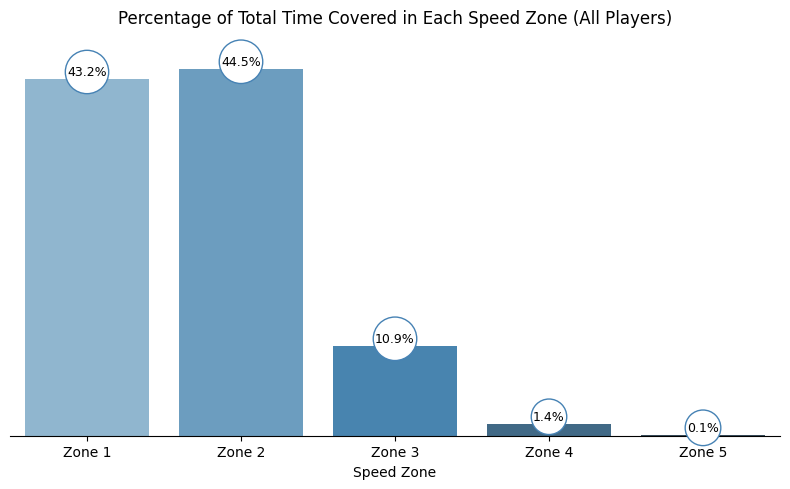

In [190]:

# List of speed zone columns 
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Compute average time (secs) for each speed zone
avg_time_secs = df[speed_zone_cols].mean()

# Total average time across all zones
total_time = avg_time_secs.sum()

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=zone_labels,
    y=avg_time_secs.values / 60,      # convert to minutes on the y-axis
    palette='Blues_d',
    dodge=False
)

# Title and axis labels
ax.set_xlabel("Speed Zone")
ax.set_title("Percentage of Total Time Covered in Each Speed Zone (All Players)", pad=20)

# Gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
sns.despine(ax=ax, top=True, right=True, left=True)

# Annotate with percentages
for i, secs in enumerate(avg_time_secs):
    pct = (secs / total_time) * 100
    ax.text(
        i, 
        (secs / 60) + 0.1,           # place label just above the bar (in minutes)
        f"{pct:.1f}%",               
        ha='center', 
        va='bottom', 
        fontsize=9,
        bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
    )

# Optionally remove y-ticks if you only want to show percentage
ax.set_yticks([])

plt.tight_layout()
plt.show()


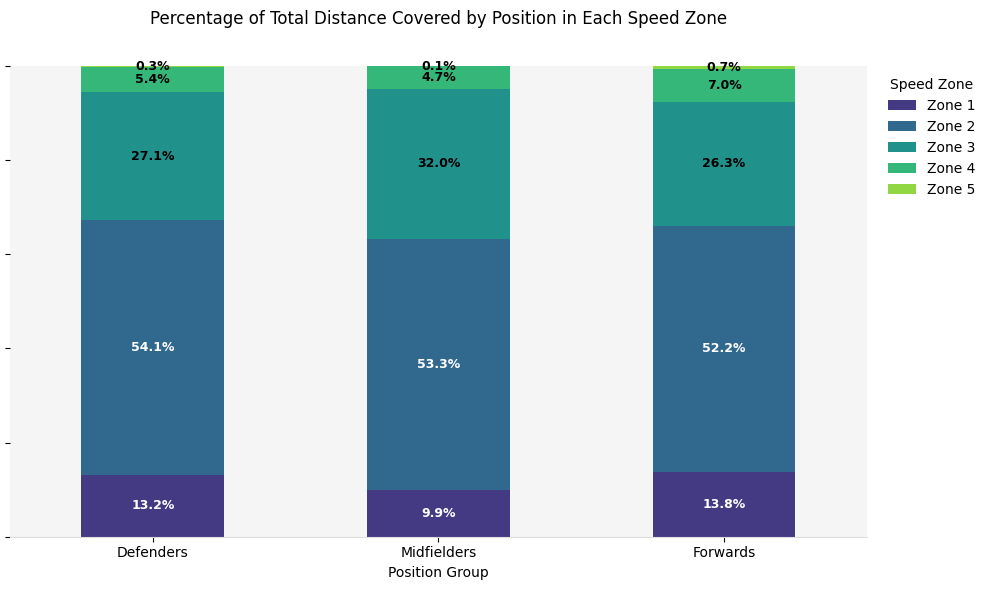

In [191]:
# Prepare data for 100% stacked bar plot: percentage distance in each speed zone grouped by position
speed_zone_cols = [
    'distance_in_speed_zone_1_km',
    'distance_in_speed_zone_2_km',
    'distance_in_speed_zone_3_km',
    'distance_in_speed_zone_4_km',
    'distance_in_speed_zone_5_km'
]

# Group by position and sum distances (in km)
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions if desired
position_order = ['Defenders', 'Midfielders', 'Forwards']
zone_by_position = zone_by_position.reindex(position_order)

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages row-wise
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Plot
ax = zone_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette('viridis', n_colors=len(zone_labels))
)

# Annotate values inside each bar segment (as percentages, one decimal)
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        height = value
        y = cumulative + height / 2
        if value > 0.05:  # Only annotate if segment is large enough
            ax.text(
                i, y, f"{value:.1f}%",
                ha='center', va='center', fontsize=9, color='black' if j > 1 else 'white', fontweight='bold'
            )
        cumulative += height

plt.xlabel('Position Group')
plt.title('Percentage of Total Distance Covered by Position in Each Speed Zone',pad=30)
plt.xticks(rotation=0)
plt.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
# Remove top, left, and right spines
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0DCDD')
ax.set_facecolor('#F5F5F5')

# Remove yaxis ticklabels and set y-axis to 0-100%
ax.set_yticklabels([])
ax.set_yticks([])

ax.set_yticks(range(0, 101, 20))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

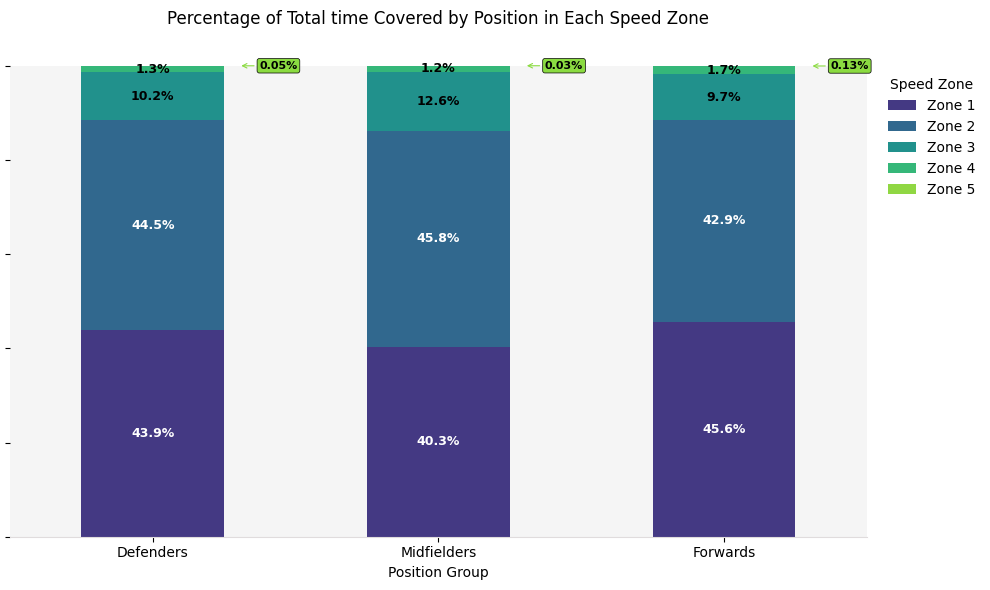

In [192]:
from matplotlib.patches import Patch

# Prepare data for 100% stacked bar plot: percentage time in each speed zone grouped by position
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Group by position and sum times (in secs)
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions if desired
position_order = ['Defenders', 'Midfielders', 'Forwards']
zone_by_position = zone_by_position.reindex(position_order)


# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages row-wise
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Plot
ax = zone_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette('viridis', n_colors=len(zone_labels))
)

# Annotate values inside each bar segment (as percentages, one decimal)
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        height = value
        y = cumulative + height / 2
        if value > 0.5:  # Only annotate if segment is large enough
            ax.text(
            i, y, f"{value:.1f}%",
            ha='center', va='center', fontsize=9, color='black' if j > 1 else 'white', fontweight='bold'
            )
        else:
            # Place a callout to the right side of the bar for small segments in Zone 5
            if zone == "Zone 5":
                ax.annotate(
                    f"{value:.2f}%",
                    xy=(i + 0.3, cumulative + height / 2),  # right side of the bar
                    xytext=(15, 0),  # offset to the right
                    textcoords='offset points',
                    ha='left',
                    va='center',
                    fontsize=8,
                    fontweight='bold',
                    color='black',
                    # Use a rounded rectangle for the callout box
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="#8BDB41", linewidth=0.5),
                    arrowprops=dict(arrowstyle='->', color='#8BDB41', lw=0.8)
                )
        cumulative += height

plt.xlabel('Position Group')
plt.title('Percentage of Total time Covered by Position in Each Speed Zone',pad=30)
plt.xticks(rotation=0)
plt.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
# Remove top, left, and right spines
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0DCDD')
ax.set_facecolor('#F5F5F5')

# Remove yaxis ticklabels and set y-axis to 0-100%
ax.set_yticklabels([])
ax.set_yticks([])

ax.set_yticks(range(0, 101, 20))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()